In [ ]:
from google.colab import drive
import os

if not os.path.ismount('/content/drive'):
    # Clear any existing content at the mount point (use with caution!)
    !rm -rf /content/drive
    drive.mount('/content/drive')
else:
    print("✅ Google Drive is already mounted!")

Mounted at /content/drive


In [ ]:
import zipfile

zip_path = "/content/drive/MyDrive/BrainTumorMRIDataset.zip"  # Update if needed
extract_path = "/content/BrainTumorMRIDataset"

# Extract the ZIP file
with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

print("✅ Extraction complete!")
print("Extracted files:", os.listdir(extract_path))

✅ Extraction complete!
Extracted files: ['Training', 'Testing']


In [ ]:
import os
import shutil
import random
import zipfile
import numpy as np
from tensorflow.keras.preprocessing.image import ImageDataGenerator, load_img, img_to_array

# Set paths
ZIP_FILE_PATH = "/content/drive/MyDrive/BrainTumorMRIDataset.zip"  # Update if needed
EXTRACTED_DATASET_PATH = "/content/BrainTumorMRIDataset"
BALANCED_DATASET_PATH = "/content/drive/MyDrive/BalancedBrainTumorDataset"

# Step 1: Extract dataset if not already extracted
if not os.path.exists(EXTRACTED_DATASET_PATH):
    print("📂 Extracting dataset...")
    with zipfile.ZipFile(ZIP_FILE_PATH, "r") as zip_ref:
        zip_ref.extractall("/content")
    print("✅ Extraction complete!")

# Define class names
classes = ["glioma", "meningioma", "pituitary", "notumor"]

# Set balanced count (smallest class count)
BALANCED_COUNT = 1321  # Adjust based on available images

# Define dataset splits
train_ratio, val_ratio, test_ratio = 0.7, 0.15, 0.15
train_count = int(BALANCED_COUNT * train_ratio)  # 925 images per class
val_count = int(BALANCED_COUNT * val_ratio)      # 198 images per class
test_count = int(BALANCED_COUNT * test_ratio)    # 198 images per class

# Create folders
for split in ["Training", "Validation", "Testing"]:
    for class_name in classes:
        os.makedirs(os.path.join(BALANCED_DATASET_PATH, split, class_name), exist_ok=True)

# Function to copy images (with folder existence check)
def copy_images(src_folder, dest_folder, num_images):
    if not os.path.exists(src_folder):
        print(f"❌ Folder not found: {src_folder}. Skipping...")
        return

    all_images = [f for f in os.listdir(src_folder) if os.path.isfile(os.path.join(src_folder, f))]
    if len(all_images) == 0:
        print(f"❌ No images found in {src_folder}. Skipping...")
        return

    selected_images = random.sample(all_images, min(len(all_images), num_images))
    for img in selected_images:
        shutil.copy(os.path.join(src_folder, img), os.path.join(dest_folder, img))

# Function to augment images
def augment_images(dest_folder, target_count):
    datagen = ImageDataGenerator(
        rotation_range=20, width_shift_range=0.1, height_shift_range=0.1,
        shear_range=0.2, zoom_range=0.2, horizontal_flip=True, fill_mode="nearest"
    )

    images = [f for f in os.listdir(dest_folder) if os.path.isfile(os.path.join(dest_folder, f))]
    num_existing = len(images)

    if num_existing >= target_count:
        return  # No need to augment

    num_to_generate = target_count - num_existing
    generated_count = 0

    while generated_count < num_to_generate:
        img_name = random.choice(images)
        img = load_img(os.path.join(dest_folder, img_name), target_size=(224, 224))
        img_array = img_to_array(img)
        img_array = np.expand_dims(img_array, axis=0)

        for batch in datagen.flow(img_array, batch_size=1, save_to_dir=dest_folder, save_prefix="aug", save_format="jpeg"):
            generated_count += 1
            if generated_count >= num_to_generate:
                break

# Process each class
for class_name in classes:
    src_train = os.path.join(EXTRACTED_DATASET_PATH, "Training", class_name)
    src_test = os.path.join(EXTRACTED_DATASET_PATH, "Testing", class_name)

    dst_train = os.path.join(BALANCED_DATASET_PATH, "Training", class_name)
    dst_val = os.path.join(BALANCED_DATASET_PATH, "Validation", class_name)
    dst_test = os.path.join(BALANCED_DATASET_PATH, "Testing", class_name)

    # Copy and augment training images
    copy_images(src_train, dst_train, train_count)
    augment_images(dst_train, train_count)

    # Copy validation images
    copy_images(src_train, dst_val, val_count)

    # Copy testing images
    copy_images(src_test, dst_test, test_count)

print("✅ Dataset is perfectly balanced!")

✅ Dataset is perfectly balanced!


In [ ]:
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import GlobalAveragePooling2D, Dense, Dropout, BatchNormalization
from tensorflow.keras.applications import EfficientNetV2L
from tensorflow.keras.applications.efficientnet_v2 import preprocess_input
from tensorflow.keras.optimizers import Adam, SGD
from tensorflow.keras.callbacks import ReduceLROnPlateau, EarlyStopping, LearningRateScheduler
from tensorflow.keras.regularizers import l2
from sklearn.utils.class_weight import compute_class_weight
import numpy as np
import os
import math

# --- Configuration ---
DATASET_PATH = "/content/drive/MyDrive/BalancedBrainTumorDataset"
IMG_SIZE = (480, 480)
BATCH_SIZE = 16
EPOCHS_TOTAL = 30
CLASS_NAMES = ["glioma", "meningioma", "pituitary", "notumor"]

# --- Data Augmentation ---
train_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input,
    rotation_range=45,
    width_shift_range=0.25,
    height_shift_range=0.25,
    shear_range=0.2,
    zoom_range=0.4,
    brightness_range=[0.5, 1.5],
    horizontal_flip=True,
    fill_mode='nearest'
)

val_test_datagen = ImageDataGenerator(preprocessing_function=preprocess_input)

train_generator = train_datagen.flow_from_directory(
    os.path.join(DATASET_PATH, "Training"),
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical'
)

val_generator = val_test_datagen.flow_from_directory(
    os.path.join(DATASET_PATH, "Validation"),
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical'
)

test_generator = val_test_datagen.flow_from_directory(
    os.path.join(DATASET_PATH, "Testing"),
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=False
)

# --- Class Weights ---
y_train = train_generator.classes
class_weights = compute_class_weight('balanced', classes=np.unique(y_train), y=y_train)
class_weights_dict = dict(enumerate(class_weights))

# --- Load Base Model ---
base_model = EfficientNetV2L(weights='imagenet', include_top=False, input_shape=(480, 480, 3))
base_model.trainable = False

# --- Build Model ---
model = Sequential([
    base_model,
    GlobalAveragePooling2D(),
    BatchNormalization(),
    Dense(1024, activation='relu', kernel_regularizer=l2(0.001)),
    Dropout(0.6),
    Dense(512, activation='relu', kernel_regularizer=l2(0.001)),
    Dropout(0.5),
    Dense(len(CLASS_NAMES), activation='softmax')
])

# --- Compile Phase 1 ---
model.compile(
    optimizer=Adam(learning_rate=1e-4),
    loss=tf.keras.losses.CategoricalCrossentropy(label_smoothing=0.1),
    metrics=['accuracy']
)

# --- Callbacks ---
early_stop = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True, verbose=1)
reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.4, patience=2, verbose=1)

# --- Phase 1: Train Top Layers ---
print("\n🔧 Training top layers...\n")
model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=10,
    class_weight=class_weights_dict,
    callbacks=[early_stop, reduce_lr],
    verbose=1
)

# --- Phase 2: Fine-tune Full Model ---
print("\n🧠 Fine-tuning entire model...\n")
base_model.trainable = True
for layer in base_model.layers[:-10]:  # Unfreeze most of the base
    layer.trainable = True

# Use SGD for fine-tuning
model.compile(
    optimizer=SGD(learning_rate=1e-4, momentum=0.9, nesterov=True),
    loss=tf.keras.losses.CategoricalCrossentropy(label_smoothing=0.05),
    metrics=['accuracy']
)

# --- Cosine Annealing Learning Rate ---
def cosine_annealing(epoch):
    max_lr = 1e-3
    min_lr = 1e-5
    return min_lr + (max_lr - min_lr) * (1 + math.cos(math.pi * epoch / EPOCHS_TOTAL)) / 2

lr_scheduler = LearningRateScheduler(cosine_annealing)

# --- Train ---
history = model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=20,  # rest of the epochs
    class_weight=class_weights_dict,
    callbacks=[early_stop, reduce_lr, lr_scheduler],
    verbose=1
)

# --- Save Model ---
model.save("efficientnetv2_99percent.keras")


Found 3696 images belonging to 4 classes.
Found 792 images belonging to 4 classes.
Found 792 images belonging to 4 classes.
473176280/473176280 ━━━━━━━━━━━━━━━━━━━━ 3s 0us/step

🔧 Training top layers...



/usr/local/lib/python3.11/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/10
231/231 ━━━━━━━━━━━━━━━━━━━━ 475s 2s/step - accuracy: 0.4405 - loss: 3.4455 - val_accuracy: 0.7538 - val_loss: 2.7252 - learning_rate: 1.0000e-04
Epoch 2/10
231/231 ━━━━━━━━━━━━━━━━━━━━ 327s 1s/step - accuracy: 0.6576 - loss: 2.8828 - val_accuracy: 0.8030 - val_loss: 2.5568 - learning_rate: 1.0000e-04
Epoch 3/10
231/231 ━━━━━━━━━━━━━━━━━━━━ 331s 1s/step - accuracy: 0.6975 - loss: 2.7582 - val_accuracy: 0.8245 - val_loss: 2.4965 - learning_rate: 1.0000e-04
Epoch 4/10
231/231 ━━━━━━━━━━━━━━━━━━━━ 325s 1s/step - accuracy: 0.7431 - loss: 2.6298 - val_accuracy: 0.8295 - val_loss: 2.4660 - learning_rate: 1.0000e-04
Epoch 5/10
231/231 ━━━━━━━━━━━━━━━━━━━━ 327s 1s/step - accuracy: 0.7578 - loss: 2.5742 - val_accuracy: 0.8611 - val_loss: 2.4262 - learning_rate: 1.0000e-04
Epoch 6/10
231/231 ━━━━━━━━━━━━━━━━━━━━ 392s 1s/step - accuracy: 0.7696 - loss: 2.5155 - val_accuracy: 0.8359 - val_loss: 2.4230 - learning_rate: 1.0000e-04
Epoch 7/10
231/231 ━━━━━━━━━━━━━━━━━━━━ 380s 1s/step - acc

In [ ]:
test_loss, test_acc = model.evaluate(test_generator, verbose=1)
print(f"\n✅ Test Accuracy: {test_acc:.4f}, Test Loss: {test_loss:.4f}")


50/50 ━━━━━━━━━━━━━━━━━━━━ 33s 643ms/step - accuracy: 0.9830 - loss: 1.6403

✅ Test Accuracy: 0.9861, Test Loss: 1.6424


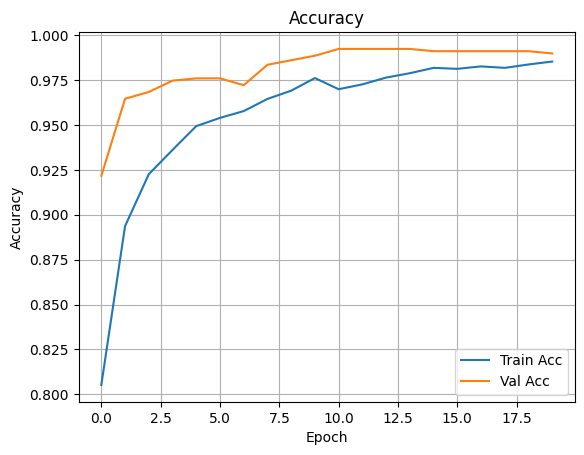

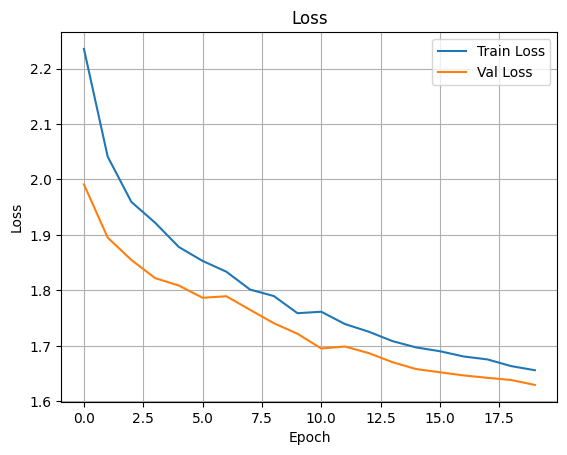

In [ ]:
import matplotlib.pyplot as plt

# Accuracy
plt.plot(history.history['accuracy'], label='Train Acc')
plt.plot(history.history['val_accuracy'], label='Val Acc')
plt.title('Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)
plt.show()

# Loss
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.title('Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)
plt.show()


50/50 ━━━━━━━━━━━━━━━━━━━━ 75s 1s/step


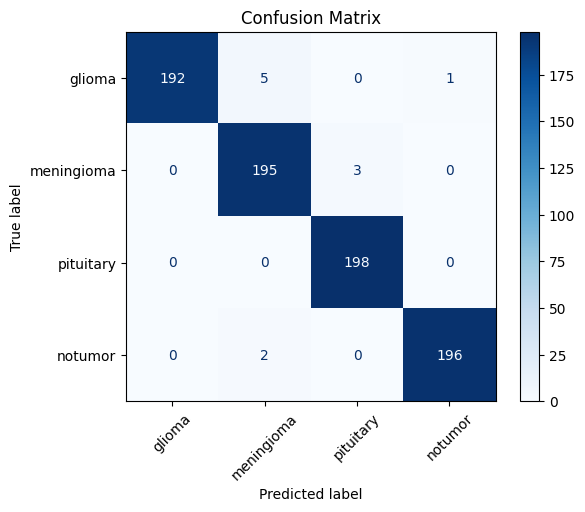

In [ ]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import numpy as np

y_true = test_generator.classes
y_pred_probs = model.predict(test_generator)
y_pred = np.argmax(y_pred_probs, axis=1)

cm = confusion_matrix(y_true, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=CLASS_NAMES)
disp.plot(cmap='Blues', xticks_rotation=45)
plt.title("Confusion Matrix")
plt.show()


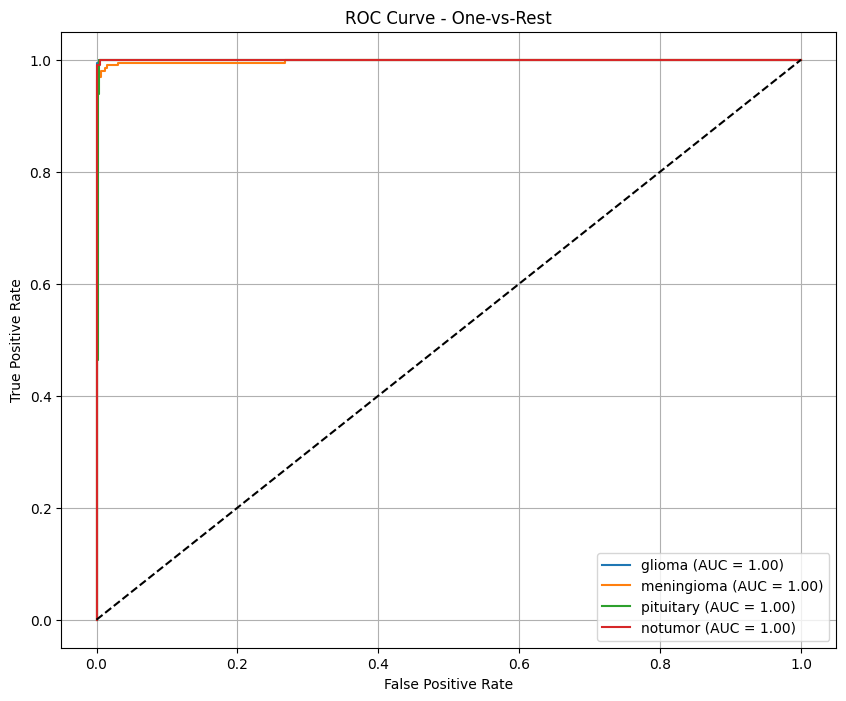

In [ ]:
from sklearn.metrics import roc_curve, auc
from sklearn.preprocessing import label_binarize

y_true_bin = label_binarize(y_true, classes=list(range(len(CLASS_NAMES))))
fpr = dict()
tpr = dict()
roc_auc = dict()

for i in range(len(CLASS_NAMES)):
    fpr[i], tpr[i], _ = roc_curve(y_true_bin[:, i], y_pred_probs[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

# Plot all ROC curves
plt.figure(figsize=(10, 8))
for i in range(len(CLASS_NAMES)):
    plt.plot(fpr[i], tpr[i], label=f'{CLASS_NAMES[i]} (AUC = {roc_auc[i]:.2f})')

plt.plot([0, 1], [0, 1], 'k--')
plt.title("ROC Curve - One-vs-Rest")
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.legend(loc='lower right')
plt.grid(True)
plt.show()


50/50 ━━━━━━━━━━━━━━━━━━━━ 33s 654ms/step


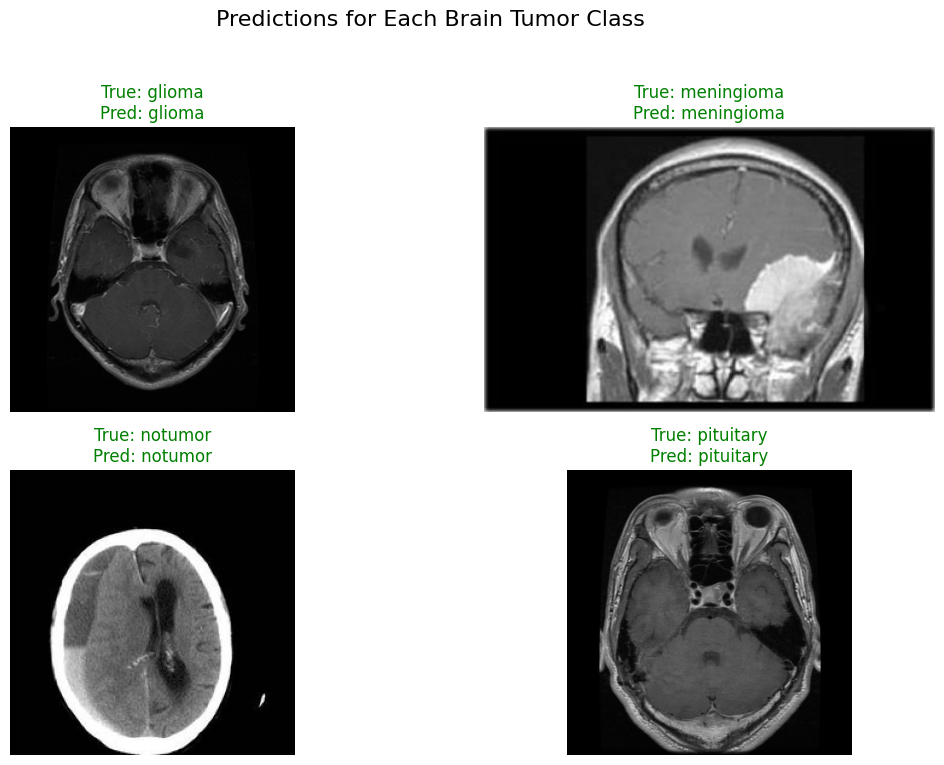

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Reset test generator and get predictions
test_generator.reset()
y_pred_probs = model.predict(test_generator)
y_pred = np.argmax(y_pred_probs, axis=1)
y_true = test_generator.classes
class_indices = test_generator.class_indices
idx_to_class = dict((v, k) for k, v in class_indices.items())

# Store one example per class
shown_classes = {}
images = []
labels_true = []
labels_pred = []

# Loop through batches until all classes are shown
for i in range(len(y_pred)):
    true_label = y_true[i]
    pred_label = y_pred[i]
    if true_label not in shown_classes:
        shown_classes[true_label] = i
        img_path = test_generator.filepaths[i]
        img = plt.imread(img_path)
        images.append(img)
        labels_true.append(idx_to_class[true_label])
        labels_pred.append(idx_to_class[pred_label])
    if len(shown_classes) == len(CLASS_NAMES):
        break

# Plot images
plt.figure(figsize=(12, 8))
for i in range(4):
    plt.subplot(2, 2, i+1)
    plt.imshow(images[i])
    is_correct = labels_true[i] == labels_pred[i]
    color = 'green' if is_correct else 'red'
    plt.title(f"True: {labels_true[i]}\nPred: {labels_pred[i]}", color=color)
    plt.axis('off')

plt.suptitle("Predictions for Each Brain Tumor Class", fontsize=16)
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()


In [ ]:
from sklearn.metrics import classification_report

# Make predictions
test_generator.reset()
y_pred_probs = model.predict(test_generator)
y_pred = np.argmax(y_pred_probs, axis=1)
y_true = test_generator.classes

# Generate classification report
report = classification_report(
    y_true,
    y_pred,
    target_names=CLASS_NAMES,
    digits=4
)

print("📋 Classification Report:\n")
print(report)


50/50 ━━━━━━━━━━━━━━━━━━━━ 32s 636ms/step
📋 Classification Report:

              precision    recall  f1-score   support

      glioma     1.0000    0.9697    0.9846       198
  meningioma     0.9653    0.9848    0.9750       198
   pituitary     0.9851    1.0000    0.9925       198
     notumor     0.9949    0.9899    0.9924       198

    accuracy                         0.9861       792
   macro avg     0.9863    0.9861    0.9861       792
weighted avg     0.9863    0.9861    0.9861       792



In [ ]:
import pandas as pd
import numpy as np

# Reset test generator and predict
test_generator.reset()
y_pred_probs = model.predict(test_generator)
y_pred = np.argmax(y_pred_probs, axis=1)
y_true = test_generator.classes

# Map class indices to names
idx_to_class = {v: k for k, v in test_generator.class_indices.items()}

# Prepare DataFrame
results_df = pd.DataFrame({
    "Filename": [os.path.basename(f) for f in test_generator.filenames],
    "TrueLabel": [idx_to_class[i] for i in y_true],
    "PredictedLabel": [idx_to_class[i] for i in y_pred],
})

# Mark correct/incorrect
results_df["Correct"] = results_df["TrueLabel"] == results_df["PredictedLabel"]
results_df["PredictionStatus"] = results_df["Correct"].map({True: "✅ Correct", False: "❌ Incorrect"})

# View summary
print(results_df.head())

# Save to CSV
results_df.to_csv("all_predictions_detailed.csv", index=False)
print("\n📁 Saved all predictions with correctness status to 'all_predictions_detailed.csv'")


50/50 ━━━━━━━━━━━━━━━━━━━━ 32s 633ms/step
           Filename TrueLabel PredictedLabel  Correct PredictionStatus
0  Te-glTr_0001.jpg    glioma         glioma     True        ✅ Correct
1  Te-glTr_0002.jpg    glioma         glioma     True        ✅ Correct
2  Te-glTr_0003.jpg    glioma         glioma     True        ✅ Correct
3  Te-glTr_0006.jpg    glioma         glioma     True        ✅ Correct
4  Te-glTr_0009.jpg    glioma         glioma     True        ✅ Correct

📁 Saved all predictions with correctness status to 'all_predictions_detailed.csv'


In [ ]:
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import GlobalAveragePooling2D, Dense, Dropout, BatchNormalization
from tensorflow.keras.applications import EfficientNetV2L
from tensorflow.keras.applications.efficientnet_v2 import preprocess_input
from tensorflow.keras.optimizers import Adam, SGD
from tensorflow.keras.callbacks import ReduceLROnPlateau, EarlyStopping, LearningRateScheduler
from tensorflow.keras.regularizers import l2
from sklearn.utils.class_weight import compute_class_weight
import numpy as np
import os
import math

# --- Configuration ---
DATASET_PATH = "/content/drive/MyDrive/BalancedBrainTumorDataset"
IMG_SIZE = (480, 480)
BATCH_SIZE = 16
EPOCHS_TOTAL = 30
CLASS_NAMES = ["glioma", "meningioma", "pituitary", "notumor"]

# --- Data Augmentation ---
train_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input,
    rotation_range=45,
    width_shift_range=0.25,
    height_shift_range=0.25,
    shear_range=0.2,
    zoom_range=0.4,
    brightness_range=[0.5, 1.5],
    horizontal_flip=True,
    fill_mode='nearest'
)

val_test_datagen = ImageDataGenerator(preprocessing_function=preprocess_input)

train_generator = train_datagen.flow_from_directory(
    os.path.join(DATASET_PATH, "Training"),
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical'
)

val_generator = val_test_datagen.flow_from_directory(
    os.path.join(DATASET_PATH, "Validation"),
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical'
)

test_generator = val_test_datagen.flow_from_directory(
    os.path.join(DATASET_PATH, "Testing"),
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=False
)

# --- Class Weights ---
y_train = train_generator.classes
class_weights = compute_class_weight('balanced', classes=np.unique(y_train), y=y_train)
class_weights_dict = dict(enumerate(class_weights))

# --- Load Base Model ---
base_model = EfficientNetV2L(weights='imagenet', include_top=False, input_shape=(480, 480, 3))
base_model.trainable = False

# --- Build Model ---
model = Sequential([
    base_model,
    GlobalAveragePooling2D(),
    BatchNormalization(),
    Dense(1024, activation='relu', kernel_regularizer=l2(0.001)),
    Dropout(0.6),
    Dense(512, activation='relu', kernel_regularizer=l2(0.001)),
    Dropout(0.5),
    Dense(len(CLASS_NAMES), activation='softmax')
])
model.summary()

Found 3696 images belonging to 4 classes.
Found 792 images belonging to 4 classes.
Found 792 images belonging to 4 classes.
473176280/473176280 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ efficientnetv2-l (Functional)   │ (None, 15, 15, 1280)   │   117,746,848 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 1280)           │         5,120 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1024)           │     1,311,744 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1024)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 512)            │       524,800 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 4)              │         2,052 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 119,590,564 (456.20 MB)

 Trainable params: 1,841,156 (7.02 MB)

 Non-trainable params: 117,749,408 (449.18 MB)